In [ ]:
!pip install econml

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("data/2024 data/with socio/winter_2024.csv")      # change season accordingly

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# =====================================================

T = df[
    [
        "temp",
        "rh"
    ]
].values

# =====================================================
# Confounders
# =====================================================

X = df[
    [
        "hour",
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Causal Forest
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(

        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )

    ),

    n_estimators=500,

    min_samples_leaf=10,

    random_state=42

)

# =====================================================
# Train
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

# =====================================================
# Marginal Effects
# =====================================================

effects = model.const_marginal_effect(X)

temp_effect = effects[:,0]

rh_effect = effects[:,1]

# =====================================================
# Average Treatment Effect
# =====================================================

print()

print("ATE (Temp → Load):",temp_effect.mean())

print("ATE (RH → Load):",rh_effect.mean())


ATE (Temp → Load): 4.938504477834504
ATE (RH → Load): 0.9471854500335846


In [ ]:
print(df['office_hours'].value_counts())

office_hours
0    5460
1    3276
Name: count, dtype: int64


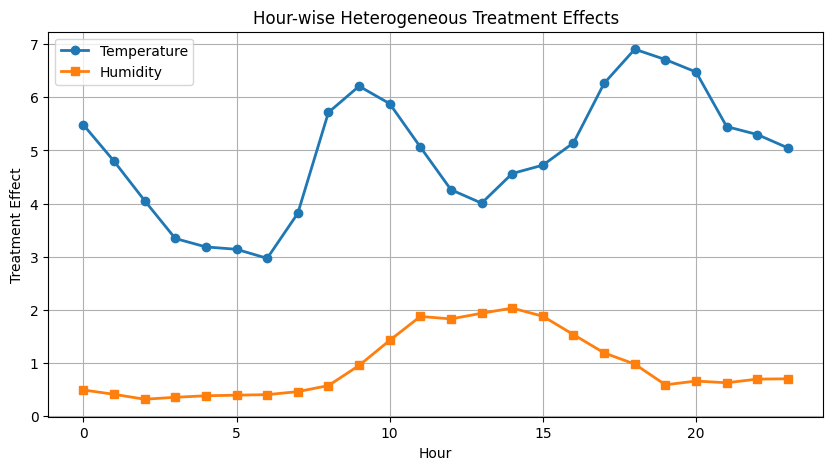

In [ ]:
# =====================================================
# STORE ROW-LEVEL WEATHER HTE VALUES
# =====================================================
# Each effect is aligned with the exact row/tuple used by EconML:
# (datetime, hour, temp, rh, weekend, holiday, festival, office_hours, ...)
# Do NOT average before storing these values.

df["temp_hte"] = temp_effect
df["rh_hte"] = rh_effect

# Save the row-level HTE values first.
# These are the individual CATE/HTE values produced by EconML,
# before any hour-wise averaging.
weather_hte_output = "winter_2024_with_hte.csv"
df.to_csv(weather_hte_output, index=False)

print(f"Saved row-level weather HTE values to: {weather_hte_output}")
print(df[[
    "hour",
    "temp",
    "rh",
    "temp_hte",
    "rh_hte"
]].head())

# =====================================================
# HOUR-WISE AVERAGE HTE
# =====================================================

plot_df = pd.DataFrame({
    "hour": df["hour"],
    "temp_effect": df["temp_hte"],
    "rh_effect": df["rh_hte"]
})

hour_effect = plot_df.groupby("hour")[
    [
        "temp_effect",
        "rh_effect"
    ]
].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(
    hour_effect["hour"],
    hour_effect["temp_effect"],
    marker="o",
    linewidth=2,
    label="Temperature"
)

plt.plot(
    hour_effect["hour"],
    hour_effect["rh_effect"],
    marker="s",
    linewidth=2,
    label="Humidity"
)

plt.xlabel("Hour")
plt.ylabel("Average Treatment Effect")
plt.title("Hour-wise Heterogeneous Treatment Effects")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# =====================================================
# LOAD DATA
# =====================================================

df = pd.read_csv("winter_2024.csv")

df = df.dropna().reset_index(drop=True)

# =====================================================
# Outcome
# =====================================================

Y = df["wdLoad"].values

# =====================================================
# Treatments
# =====================================================

T = df[
    [
        "weekend",
        "holiday",
        "festival",
        "office_hours"
    ]
].values

# =====================================================
# Confounders
# =====================================================

X = df[
    [
        "temp",
        "rh",
        "hour"
    ]
].values

# =====================================================
# CAUSAL FOREST
# =====================================================

model = CausalForestDML(

    model_y=RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    model_t=MultiOutputRegressor(
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        )
    ),

    n_estimators=500,
    min_samples_leaf=10,
    random_state=42
)

# =====================================================
# TRAIN
# =====================================================

model.fit(
    Y,
    T,
    X=X
)

print("Model trained successfully!")

# =====================================================
# MARGINAL EFFECTS
# =====================================================

effects = model.const_marginal_effect(X)

print("Effect Matrix Shape :", effects.shape)

weekend_effect = effects[:,0]
holiday_effect = effects[:,1]
festival_effect = effects[:,2]
office_effect = effects[:,3]

# =====================================================
# ATE
# =====================================================

print("\n========== Average Treatment Effects ==========")

print("ATE (Weekend → Load):      ", weekend_effect.mean())

print("ATE (Holiday → Load):      ", holiday_effect.mean())

print("ATE (Festival → Load):     ", festival_effect.mean())

print("ATE (Office Hours → Load): ", office_effect.mean())

Model trained successfully!
Effect Matrix Shape : (8736, 4)

========== Average Treatment Effects ==========
ATE (Weekend → Load):       -49.468113409850766
ATE (Holiday → Load):       -25.077375179453014
ATE (Festival → Load):      12.586846633237567
ATE (Office Hours → Load):  0.0


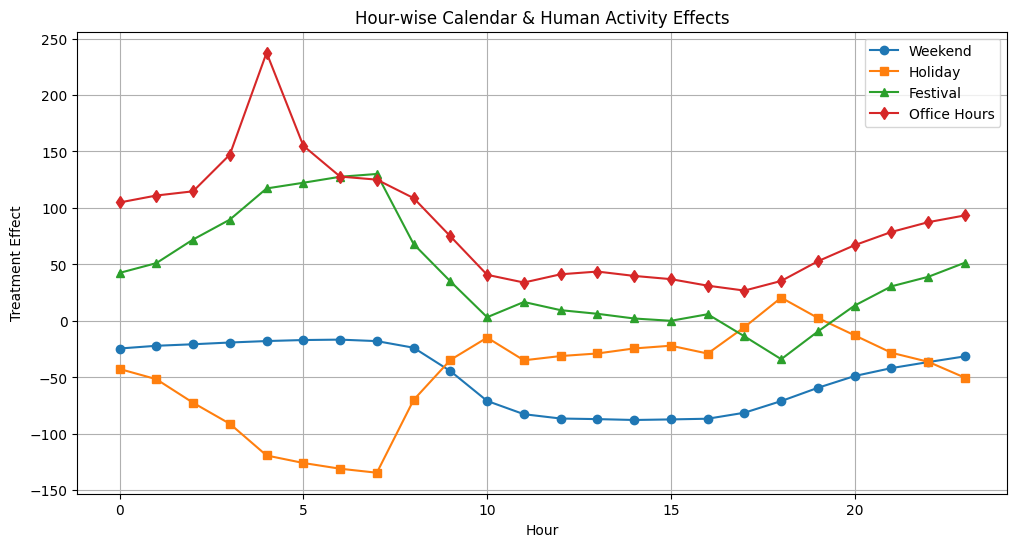

In [ ]:
# =====================================================
# STORE ROW-LEVEL CALENDAR HTE VALUES
# =====================================================
# Each treatment effect remains attached to the exact observation/tuple
# from which EconML estimated the effect.

df["weekend_hte"] = weekend_effect
df["holiday_hte"] = holiday_effect
df["festival_hte"] = festival_effect
df["office_hte"] = office_effect

# Save the complete dataset containing BOTH weather and calendar
# row-level HTE values. No averaging is performed before this save.
hte_output = "winter_2024_with_all_hte.csv"
df.to_csv(hte_output, index=False)

print(f"Saved row-level weather + calendar HTE values to: {hte_output}")

print(df[[
    "hour",
    "temp",
    "rh",
    "weekend",
    "holiday",
    "festival",
    "office_hours",
    "weekend_hte",
    "holiday_hte",
    "festival_hte",
    "office_hte"
]].head())

# =====================================================
# HOUR-WISE AVERAGE HTE
# =====================================================

plot_df = pd.DataFrame({
    "hour": df["hour"],
    "Weekend": df["weekend_hte"],
    "Holiday": df["holiday_hte"],
    "Festival": df["festival_hte"],
    "Office": df["office_hte"]
})

hour_effect = plot_df.groupby("hour").mean()

plt.figure(figsize=(12,6))

plt.plot(
    hour_effect.index,
    hour_effect["Weekend"],
    marker="o",
    label="Weekend"
)

plt.plot(
    hour_effect.index,
    hour_effect["Holiday"],
    marker="s",
    label="Holiday"
)

plt.plot(
    hour_effect.index,
    hour_effect["Festival"],
    marker="^",
    label="Festival"
)

plt.plot(
    hour_effect.index,
    hour_effect["Office"],
    marker="d",
    label="Office Hours"
)

plt.grid(True)
plt.legend()
plt.xlabel("Hour")
plt.ylabel("Average Treatment Effect")
plt.title("Hour-wise Calendar & Human Activity Effects")
plt.show()


In [ ]:
print(df[['hour', 'office_hours']].corr())

                  hour  office_hours
hour          1.000000      0.167851
office_hours  0.167851      1.000000
